# Trực quan hóa dữ liệu

In [ ]:
!pip install -U openai-whisper


In [ ]:
import whisper

model = whisper.load_model("small")

result = model.transcribe(
    "/content/an2.mp3",
    language="vi"
)

print("Nội dung giọng nói:")
print(result["text"])


100%|████████████████████████████████████████| 461M/461M [00:03<00:00, 121MiB/s]
/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


Nội dung giọng nói:
 Tín hiệu chúng ta luôn cần phải xoay cắt tín hiệu với nhau chẳng hát như vấn đề của tín hiệu radar radar sẽ bắt tín hiệu để tìm một tiêu tín hiệu này ra nó sẽ đập vào một tiêu như máy bay và phát ra trở lại radar


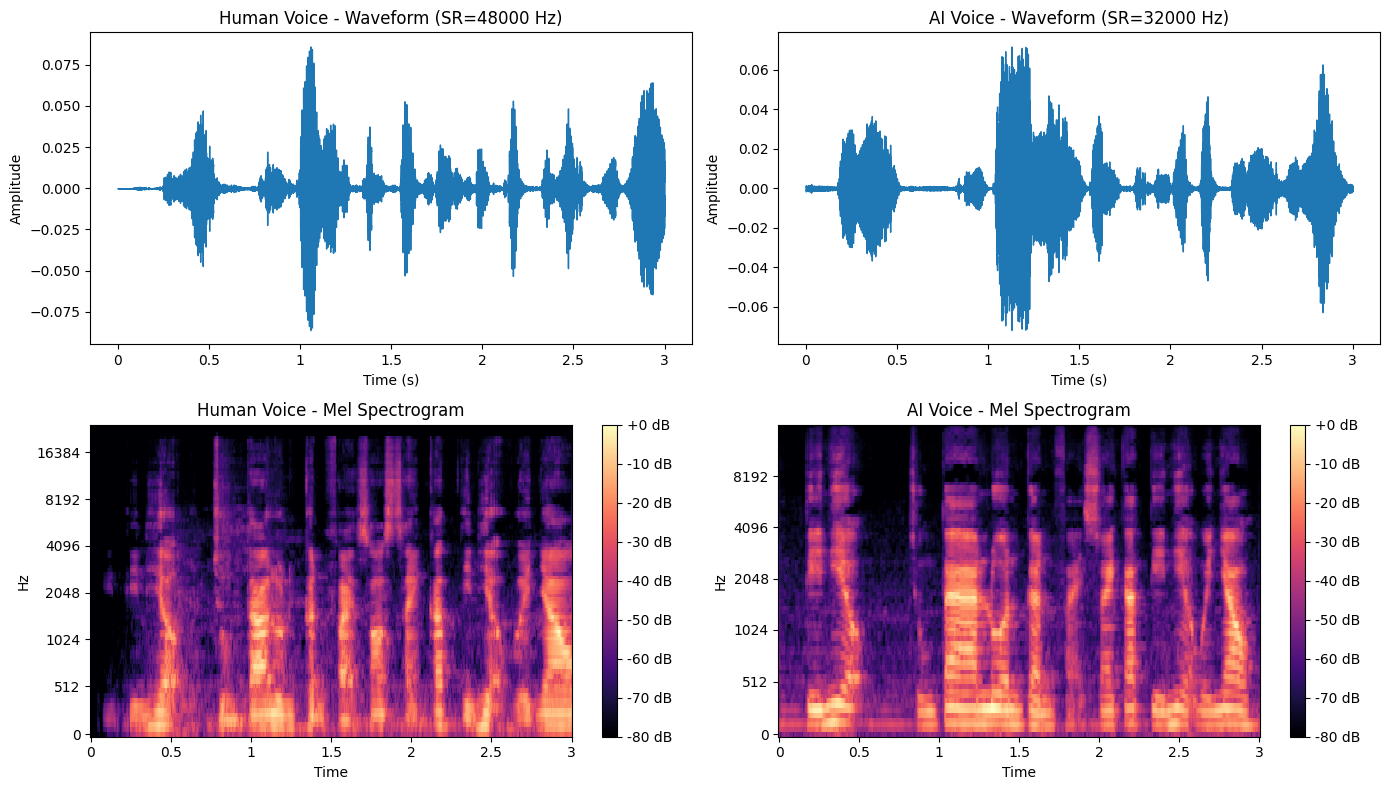

In [ ]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

N_MELS = 80
HOP = 256
N_FFT = 1024
DURATION = 3.0

def load_audio_raw(path, duration=DURATION):
    audio, sr = librosa.load(
        path,
        sr=None,
        mono=True,
        duration=duration
    )
    return audio, sr

def get_mel(audio, sr):
    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP,
        n_mels=N_MELS,
        fmax=sr // 2
    )
    return librosa.power_to_db(mel, ref=np.max)

def visualize_ai_vs_human(human_path, ai_path):
    human_audio, human_sr = load_audio_raw(human_path)
    ai_audio, ai_sr = load_audio_raw(ai_path)

    human_mel = get_mel(human_audio, human_sr)
    ai_mel = get_mel(ai_audio, ai_sr)

    plt.figure(figsize=(14, 8))

    plt.subplot(2, 2, 1)
    librosa.display.waveshow(human_audio, sr=human_sr)
    plt.title(f"Human Voice - Waveform (SR={human_sr} Hz)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")

    plt.subplot(2, 2, 2)
    librosa.display.waveshow(ai_audio, sr=ai_sr)
    plt.title(f"AI Voice - Waveform (SR={ai_sr} Hz)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")

    plt.subplot(2, 2, 3)
    librosa.display.specshow(
        human_mel,
        sr=human_sr,
        hop_length=HOP,
        x_axis="time",
        y_axis="mel"
    )
    plt.title("Human Voice - Mel Spectrogram")
    plt.colorbar(format="%+2.0f dB")

    plt.subplot(2, 2, 4)
    librosa.display.specshow(
        ai_mel,
        sr=ai_sr,
        hop_length=HOP,
        x_axis="time",
        y_axis="mel"
    )
    plt.title("AI Voice - Mel Spectrogram")
    plt.colorbar(format="%+2.0f dB")

    plt.tight_layout()
    plt.show()

visualize_ai_vs_human(
    human_path="/content/an2.mp3",
    ai_path="/content/an2_ai.mp3"
)


# Tiền xử lý hoàn chỉnh

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pydub librosa soundfile webrtcvad

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for webrtcvad: filename=webrtcvad-2.0.10-cp312-cp312-linux_x86_64.whl size=73515 sha256=4eb3a51f8c4d631b55e95efcf1016559a9c2a5015a11fbd611470e6594ea06c2
  Stored in directory: /root/.cache/pip/wheels/1e/d3/95/680fa3b16848f1a58d2edaed34c496224c89a9bc63e17b3614
Successfully built webrtcvad


In [ ]:
import os
import librosa
import numpy as np
import soundfile as sf
from tqdm import tqdm

SR = 16000
TARGET_RMS = 0.08
CROP_SEC = 4.0
HOP_SEC = 2.0
MIN_SEC = 1.5
ENERGY_TH = 1e-4

OUT_ROOT = "/content/audio_pre_aasist_v2"

def find_audio_files(folder):
    exts = (".wav", ".mp3", ".flac", ".m4a", ".aac", ".ogg", ".opus")
    paths = []
    for root, _, files in os.walk(folder):
        for f in files:
            if f.lower().endswith(exts):
                paths.append(os.path.join(root, f))
    return paths

def load_audio(path, sr=SR):
    audio, _ = librosa.load(path, sr=sr, mono=True)
    return audio.astype(np.float32), sr

def normalize_soft(audio, target_rms=TARGET_RMS):
    rms = np.sqrt(np.mean(audio ** 2) + 1e-9)
    scale = min(target_rms / rms, 3.0)
    return audio * scale

def sliding_crop_energy(audio, sr):
    crop_len = int(sr * CROP_SEC)
    hop_len = int(sr * HOP_SEC)
    min_len = int(sr * MIN_SEC)

    if len(audio) < min_len:
        return []

    if len(audio) <= crop_len:
        if np.mean(audio ** 2) > ENERGY_TH:
            return [audio]
        return []

    segments = []
    for start in range(0, len(audio) - crop_len + 1, hop_len):
        seg = audio[start:start + crop_len]
        if np.mean(seg ** 2) > ENERGY_TH:
            segments.append(seg)

    return segments

def safe_name(path):
    base = os.path.splitext(os.path.basename(path))[0]
    return "".join(c if c.isalnum() or c in "_-" else "_" for c in base)

def process_file(input_path, output_folder, prefix):
    try:
        audio, sr = load_audio(input_path)
        audio = normalize_soft(audio)
        segments = sliding_crop_energy(audio, sr)

        if len(segments) == 0:
            return 0

        base = safe_name(input_path)

        for i, seg in enumerate(segments):
            out_path = os.path.join(output_folder, f"{prefix}_{base}_{i:04d}.wav")
            sf.write(out_path, seg, sr, subtype="PCM_16")

        return len(segments)

    except Exception as e:
        print("Error:", input_path, e)
        return 0

def process_folder(input_folder, output_folder, prefix):
    os.makedirs(output_folder, exist_ok=True)

    files = find_audio_files(input_folder)
    print(f"{input_folder} | {len(files)} files")

    total_segments = 0
    for f in tqdm(files):
        total_segments += process_file(f, output_folder, prefix)

    hours = total_segments * CROP_SEC / 3600
    print(prefix, "segments:", total_segments)
    print(prefix, "approx hours:", hours)

process_folder(
    "/content/drive/MyDrive/ChuyenDe/data/giọng người và data kaggle",
    f"{OUT_ROOT}/human",
    "human"
)

process_folder(
    "/content/drive/MyDrive/ChuyenDe/data/13 12 clone voice",
    f"{OUT_ROOT}/ai",
    "ai"
)

process_folder(
    "/content/drive/MyDrive/ChuyenDe/data/data_AIYT",
    f"{OUT_ROOT}/ai",
    "ai"
)

process_folder(
    "/content/drive/MyDrive/ChuyenDe/data/ai clone voice",
    f"{OUT_ROOT}/ai",
    "ai"
)

print("DONE PREPROCESSING")

/content/drive/MyDrive/ChuyenDe/data/giọng người và data kaggle | 756 files


100%|██████████| 756/756 [00:19<00:00, 39.11it/s]


/content/drive/MyDrive/ChuyenDe/data/13 12 clone voice | 43 files


100%|██████████| 43/43 [00:01<00:00, 29.01it/s]


/content/drive/MyDrive/ChuyenDe/data/data_AIYT | 27 files


100%|██████████| 27/27 [00:26<00:00,  1.03it/s]


/content/drive/MyDrive/ChuyenDe/data/ai clone voice | 77 files


100%|██████████| 77/77 [00:01<00:00, 44.97it/s]

DONE PREPROCESSING


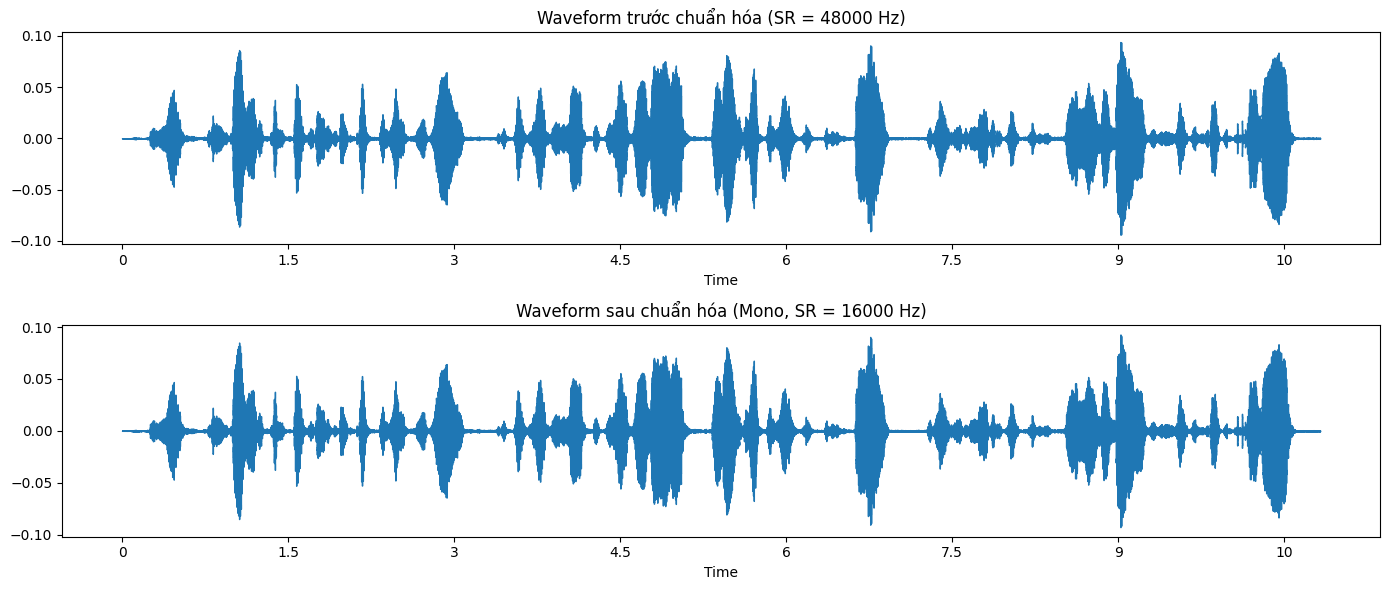

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# ====== LOAD AUDIO GỐC (GIỮ NGUYÊN SR) ======
path = "/content/an2.mp3"  # đổi thành file bất kỳ

audio_raw, sr_raw = librosa.load(path, sr=None, mono=False)

# Nếu stereo → lấy 1 kênh để vẽ
if audio_raw.ndim > 1:
    audio_raw_plot = audio_raw[0]
else:
    audio_raw_plot = audio_raw

# ====== LOAD AUDIO SAU CHUẨN HÓA ======
audio_norm, sr_norm = librosa.load(path, sr=16000, mono=True)

# ====== VẼ ======
plt.figure(figsize=(14, 6))

plt.subplot(2, 1, 1)
librosa.display.waveshow(audio_raw_plot, sr=sr_raw)
plt.title(f"Waveform trước chuẩn hóa (SR = {sr_raw} Hz)")

plt.subplot(2, 1, 2)
librosa.display.waveshow(audio_norm, sr=sr_norm)
plt.title("Waveform sau chuẩn hóa (Mono, SR = 16000 Hz)")

plt.tight_layout()
plt.show()


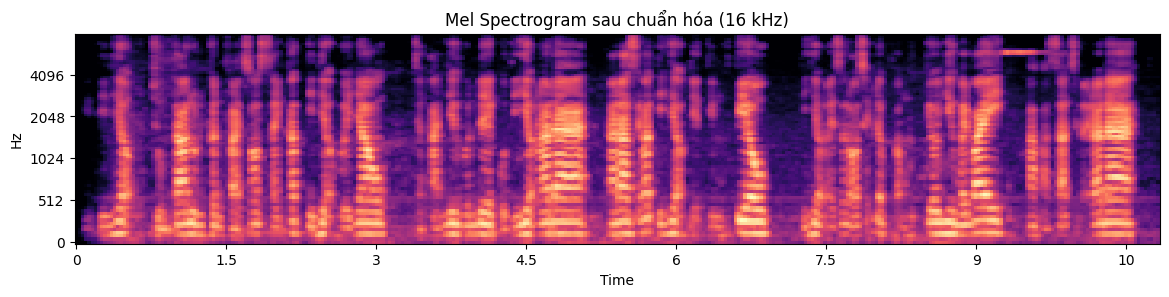

In [ ]:
# ====== MEL SPECTROGRAM ======
mel_raw = librosa.feature.melspectrogram(
    y=audio_raw_plot, sr=sr_raw, n_mels=80
)
mel_norm = librosa.feature.melspectrogram(
    y=audio_norm, sr=16000, n_mels=80
)

mel_raw_db = librosa.power_to_db(mel_raw, ref=np.max)
mel_norm_db = librosa.power_to_db(mel_norm, ref=np.max)

plt.figure(figsize=(14, 6))



plt.subplot(2, 1, 2)
librosa.display.specshow(mel_norm_db, sr=16000, x_axis="time", y_axis="mel")
plt.title("Mel Spectrogram sau chuẩn hóa (16 kHz)")


plt.show()


In [ ]:
import librosa
import numpy as np

# ================= CONFIG =================
SR = 16000
TARGET_RMS = 0.08
PATH = "/content/an2.mp3"

# ================= LOAD AUDIO =================
audio, sr = librosa.load(PATH, sr=SR, mono=True)

# ================= RMS =================
def compute_rms(x):
    return np.sqrt(np.mean(x**2) + 1e-9)

rms_before = compute_rms(audio)

# ================= NORMALIZE RMS =================
scale = min(TARGET_RMS / rms_before, 3.0)
audio_norm = audio * scale
rms_after = compute_rms(audio_norm)

# ================= PRINT =================
print("RMS trước chuẩn hóa :", round(rms_before, 5))
print("RMS sau chuẩn hóa   :", round(rms_after, 5))
print("Hệ số scale         :", round(scale, 3))


RMS trước chuẩn hóa : 0.01038
RMS sau chuẩn hóa   : 0.03113
Hệ số scale         : 3.0


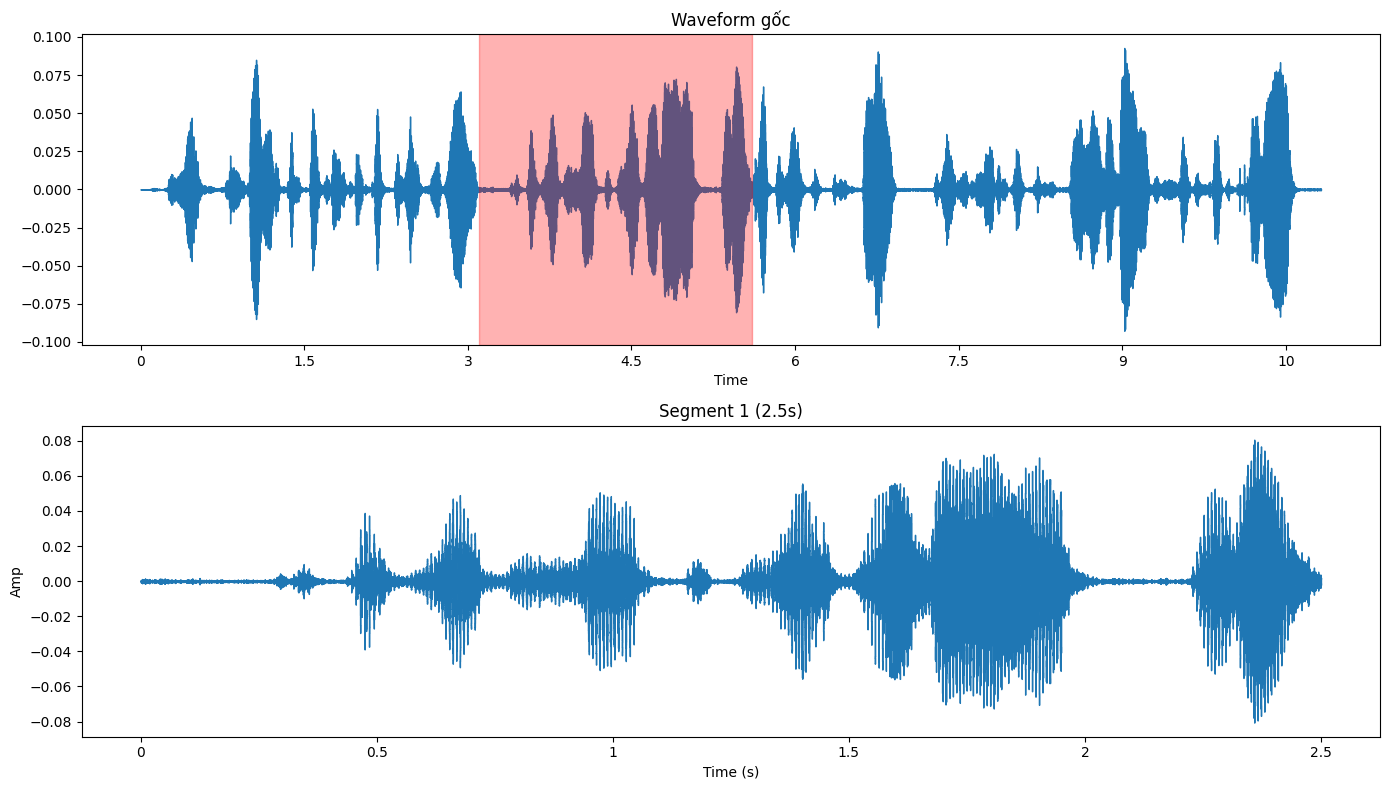

In [ ]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

# ================= CONFIG =================
SR = 16000
CROP_SEC = 2.5
MIN_SEC = 1.5
NUM_CROPS = 2
ENERGY_TH = 1e-4
PATH = "/content/an2.mp3"   # đổi file nếu cần

# ================= LOAD =================
audio, sr = librosa.load(PATH, sr=SR, mono=True)
duration = len(audio) / sr

# ================= RANDOM CROP =================
def random_crop_energy(audio, sr):
    crops = []
    positions = []

    crop_len = int(sr * CROP_SEC)
    min_len = int(sr * MIN_SEC)

    if len(audio) < min_len:
        return crops, positions

    for _ in range(NUM_CROPS):
        start = np.random.randint(0, max(1, len(audio) - crop_len))
        seg = audio[start:start + crop_len]

        if np.mean(seg ** 2) > ENERGY_TH:
            crops.append(seg)
            positions.append((start / sr, (start + len(seg)) / sr))

    return crops, positions

segments, positions = random_crop_energy(audio, sr)

# ================= VISUALIZE =================
plt.figure(figsize=(14, 8))

# ===== Waveform gốc =====
plt.subplot(len(segments) + 1, 1, 1)
librosa.display.waveshow(audio, sr=sr)
plt.title("Waveform gốc")

# Vẽ vùng crop
for (s, e) in positions:
    plt.axvspan(s, e, color="red", alpha=0.3)

# ===== Waveform từng segment =====
for i, seg in enumerate(segments):
    plt.subplot(len(segments) + 1, 1, i + 2)
    librosa.display.waveshow(seg, sr=sr)
    plt.title(f"Segment {i+1} ({len(seg)/sr:.1f}s)")
    plt.ylabel("Amp")

plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()


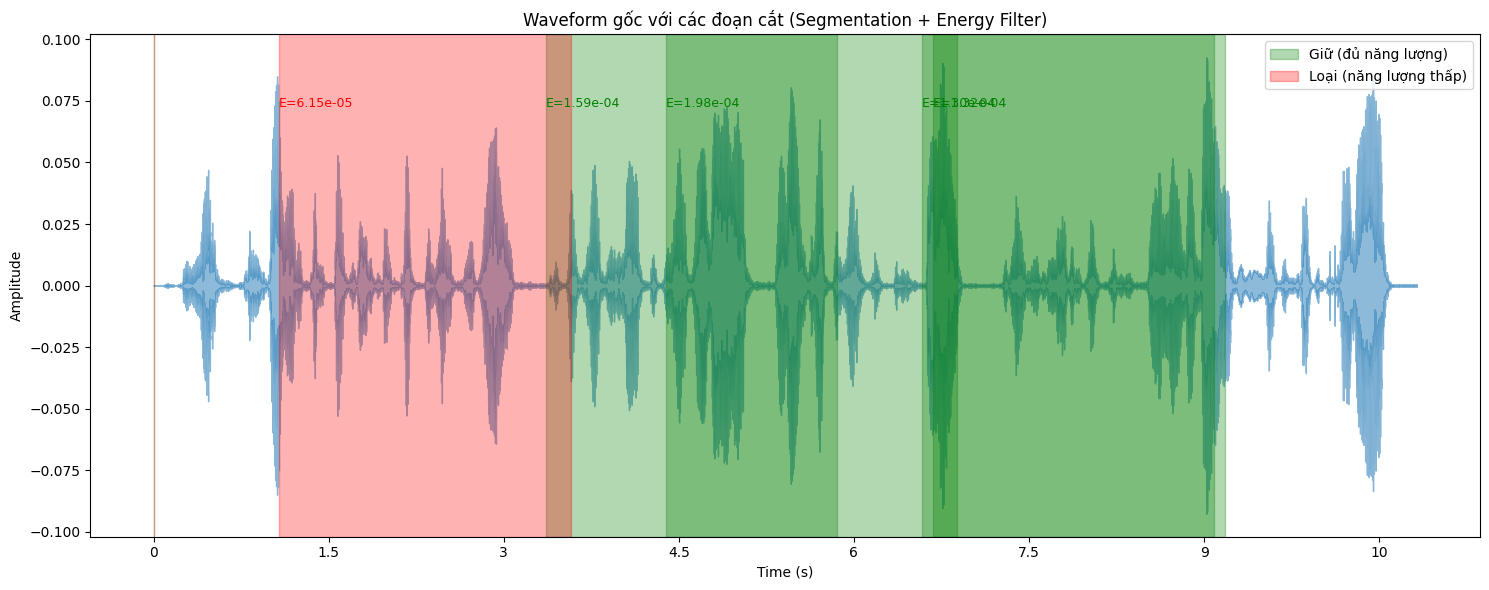

In [ ]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

# ================= CONFIG =================
SR = 16000
CROP_SEC = 2.5
NUM_CROPS = 5
ENERGY_TH = 1e-4
PATH = "/content/an2.mp3"

# ================= LOAD + NORMALIZE =================
audio, sr = librosa.load(PATH, sr=SR, mono=True)

def rms_energy(x):
    return np.mean(x ** 2)

# ================= RANDOM CROP =================
crop_len = int(SR * CROP_SEC)

segments = []
positions = []

for _ in range(NUM_CROPS):
    start = np.random.randint(0, len(audio) - crop_len)
    seg = audio[start:start + crop_len]
    energy = rms_energy(seg)
    segments.append((seg, energy))
    positions.append(start)

# ================= PLOT =================
plt.figure(figsize=(15, 6))
librosa.display.waveshow(audio, sr=SR, alpha=0.5)
plt.title("Waveform gốc với các đoạn cắt (Segmentation + Energy Filter)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

for (seg, energy), start in zip(segments, positions):
    start_t = start / SR
    end_t = (start + crop_len) / SR

    if energy > ENERGY_TH:
        color = "green"
        label = "Giữ (đủ năng lượng)"
    else:
        color = "red"
        label = "Loại (năng lượng thấp)"

    plt.axvspan(start_t, end_t, color=color, alpha=0.3)
    plt.text(start_t, 0.8*np.max(audio),
             f"E={energy:.2e}",
             color=color, fontsize=9)

# chú thích
plt.axvspan(0, 0, color="green", alpha=0.3, label="Giữ (đủ năng lượng)")
plt.axvspan(0, 0, color="red", alpha=0.3, label="Loại (năng lượng thấp)")
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()


# Mô hình Conformer (CNN + Transformer)

In [ ]:
# =========================
# MINI CONFORMER HUMAN VS AI - ONE CELL
# =========================

!pip install -q torchaudio soundfile librosa tqdm scikit-learn

from google.colab import drive
drive.mount("/content/drive")

import os
import random
import numpy as np
import soundfile as sf
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from torch.utils.data import Dataset, DataLoader

# =========================
# CONFIG
# =========================

DATA_ROOT = "/content/drive/MyDrive/ChuyenDe/audio_pre_aasist_v2"
OUT_DIR = "/content/conformer_runs/conformer_v1"

SR = 16000
N_MELS = 64
N_FFT = 512
HOP = 160
MAX_LEN = 400          # ~4 seconds
BATCH = 32
EPOCHS = 20
LR = 1e-4
DROPOUT = 0.3
PATIENCE = 5
MIN_EPOCH = 4
NUM_WORKERS = 2
SEED = 42

os.makedirs(OUT_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# =========================
# FILE LIST + SPLIT
# label: ai=0, human=1
# =========================

def collect_files(root):
    rows = []

    for cls, label in [("ai", 0), ("human", 1)]:
        folder = os.path.join(root, cls)

        for f in os.listdir(folder):
            if f.lower().endswith(".wav"):
                rows.append((os.path.join(folder, f), label))

    random.shuffle(rows)
    return rows

items = collect_files(DATA_ROOT)
paths = [x[0] for x in items]
labels = [x[1] for x in items]

train_items, temp_items = train_test_split(
    items,
    test_size=0.3,
    random_state=SEED,
    stratify=labels,
)

temp_labels = [x[1] for x in temp_items]

val_items, test_items = train_test_split(
    temp_items,
    test_size=0.5,
    random_state=SEED,
    stratify=temp_labels,
)

def count_items(name, split):
    ai = sum(1 for _, y in split if y == 0)
    human = sum(1 for _, y in split if y == 1)
    print(f"{name}: total={len(split)} | ai={ai} | human={human}")

count_items("train", train_items)
count_items("val", val_items)
count_items("test", test_items)

# =========================
# DATASET
# =========================

class VoiceDataset(Dataset):
    def __init__(self, items, augment=False):
        self.items = items
        self.augment = augment

        self.mel = torchaudio.transforms.MelSpectrogram(
            sample_rate=SR,
            n_fft=N_FFT,
            hop_length=HOP,
            n_mels=N_MELS,
            power=2.0,
        )

        self.db = torchaudio.transforms.AmplitudeToDB()

    def __len__(self):
        return len(self.items)

    def fix_length(self, mel):
        t = mel.shape[1]

        if t < MAX_LEN:
            mel = F.pad(mel, (0, MAX_LEN - t))
        else:
            if self.augment:
                start = random.randint(0, t - MAX_LEN)
                mel = mel[:, start:start + MAX_LEN]
            else:
                mel = mel[:, :MAX_LEN]

        return mel

    def augment_audio(self, wav):
        if random.random() < 0.3:
            wav = wav + 0.002 * torch.randn_like(wav)

        if random.random() < 0.3:
            wav = wav * random.uniform(0.8, 1.2)

        return wav

    def __getitem__(self, idx):
        path, label = self.items[idx]

        wav, sr = sf.read(path)

        if wav.ndim > 1:
            wav = wav.mean(axis=1)

        wav = torch.tensor(wav, dtype=torch.float32)

        if sr != SR:
            wav = torchaudio.functional.resample(wav, sr, SR)

        if self.augment:
            wav = self.augment_audio(wav)

        mel = self.db(self.mel(wav))

        mel = (mel - mel.mean()) / (mel.std() + 1e-6)
        mel = self.fix_length(mel)

        return mel, torch.tensor(label, dtype=torch.float32)

train_ds = VoiceDataset(train_items, augment=True)
val_ds = VoiceDataset(val_items, augment=False)
test_ds = VoiceDataset(test_items, augment=False)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

# =========================
# MODEL
# =========================

class ConvSubsampling(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 24, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(24, 24, 3, stride=2, padding=1),
            nn.ReLU(),
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv(x)

        b, c, f, t = x.shape
        x = x.reshape(b, c * f, t)

        return x.transpose(1, 2)

ENC_DIM = 24 * (N_MELS // 4)

class ConformerBlock(nn.Module):
    def __init__(self, dim, heads=2):
        super().__init__()

        self.ff1 = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, dim * 2),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(dim * 2, dim),
        )

        self.attn = nn.MultiheadAttention(
            dim,
            heads,
            dropout=DROPOUT,
            batch_first=True,
        )

        self.norm_attn = nn.LayerNorm(dim)

        self.conv = nn.Sequential(
            nn.Conv1d(dim, dim, kernel_size=15, padding=7, groups=dim),
            nn.BatchNorm1d(dim),
            nn.GELU(),
            nn.Conv1d(dim, dim, kernel_size=1),
        )

        self.norm_conv = nn.LayerNorm(dim)

        self.ff2 = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, dim * 2),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(dim * 2, dim),
        )

        self.norm_out = nn.LayerNorm(dim)

    def forward(self, x):
        x = x + 0.5 * self.ff1(x)

        attn_out, _ = self.attn(x, x, x)
        x = self.norm_attn(x + attn_out)

        conv_out = self.conv(x.transpose(1, 2)).transpose(1, 2)
        x = self.norm_conv(x + conv_out)

        x = x + 0.5 * self.ff2(x)

        return self.norm_out(x)

class AttentivePooling(nn.Module):
    def __init__(self, dim):
        super().__init__()

        self.att = nn.Sequential(
            nn.Linear(dim, dim // 2),
            nn.Tanh(),
            nn.Linear(dim // 2, 1),
        )

    def forward(self, x):
        w = torch.softmax(self.att(x), dim=1)
        return (x * w).sum(dim=1)

class AntiDeepfakeConformer(nn.Module):
    def __init__(self):
        super().__init__()

        self.subsample = ConvSubsampling()

        self.encoder = nn.Sequential(
            ConformerBlock(ENC_DIM),
            ConformerBlock(ENC_DIM),
        )

        self.pool = AttentivePooling(ENC_DIM)

        self.fc = nn.Sequential(
            nn.Linear(ENC_DIM, 64),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = self.subsample(x)
        x = self.encoder(x)
        x = self.pool(x)
        x = self.fc(x)

        return x.squeeze(1)

model = AntiDeepfakeConformer().to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total params: {total_params / 1e6:.2f}M")

# =========================
# LOSS / OPTIMIZER
# =========================

train_labels = np.array([y for _, y in train_items])
num_ai = np.sum(train_labels == 0)
num_human = np.sum(train_labels == 1)

pos_weight = torch.tensor(
    [num_ai / max(num_human, 1)],
    dtype=torch.float32,
    device=DEVICE,
)

print("pos_weight:", float(pos_weight.item()))

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=5e-4,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=1,
)

# =========================
# METRICS
# =========================

def compute_eer(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob, pos_label=1)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fnr - fpr))
    return float((fpr[idx] + fnr[idx]) / 2)

def compute_acc(y_true, y_prob):
    pred = (np.array(y_prob) >= 0.5).astype(int)
    return accuracy_score(y_true, pred)

def safe_auc(y_true, y_prob):
    if len(set(y_true)) < 2:
        return 0.0
    return roc_auc_score(y_true, y_prob)

def run_epoch(model, loader, optimizer=None, name="train"):
    train = optimizer is not None
    model.train() if train else model.eval()

    losses = []
    probs = []
    labels = []

    for x, y in tqdm(loader, desc=name, leave=False):
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        with torch.set_grad_enabled(train):
            out = model(x)
            loss = loss_fn(out, y)

            if train:
                optimizer.zero_grad()
                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    5.0,
                )

                optimizer.step()

        prob = torch.sigmoid(out)

        probs.extend(prob.detach().cpu().numpy().tolist())
        labels.extend(y.detach().cpu().numpy().tolist())
        losses.append(loss.item())

    auc = safe_auc(labels, probs)
    eer = compute_eer(labels, probs)
    acc = compute_acc(labels, probs)

    return np.mean(losses), auc, eer, acc

# =========================
# TRAIN LOOP
# =========================

best_eer = 1.0
wait = 0

best_path = os.path.join(OUT_DIR, "anti_ai_conformer_best.pt")
mobile_path = os.path.join(OUT_DIR, "anti_ai_mobile.pt")

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    tr_loss, tr_auc, tr_eer, tr_acc = run_epoch(
        model,
        train_loader,
        optimizer,
        name="train",
    )

    val_loss, val_auc, val_eer, val_acc = run_epoch(
        model,
        val_loader,
        optimizer=None,
        name="val",
    )

    print(
        f"Train loss={tr_loss:.4f} AUC={tr_auc:.4f} EER={tr_eer:.4f} ACC={tr_acc:.4f} | "
        f"Val loss={val_loss:.4f} AUC={val_auc:.4f} EER={val_eer:.4f} ACC={val_acc:.4f}"
    )

    scheduler.step(val_eer)

    if val_eer < best_eer:
        best_eer = val_eer
        wait = 0

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "eer": float(best_eer),
                "epoch": epoch,
                "config": {
                    "sr": SR,
                    "n_mels": N_MELS,
                    "n_fft": N_FFT,
                    "hop": HOP,
                    "max_len": MAX_LEN,
                    "labels": {"ai": 0, "human": 1},
                },
            },
            best_path,
        )

        print(f"Saved Best: {best_path} | EER={best_eer:.4f}")

    else:
        wait += 1

        if epoch >= MIN_EPOCH and wait >= PATIENCE:
            print("Early stopping")
            break

# =========================
# TEST BEST
# =========================

ckpt = torch.load(best_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])

test_loss, test_auc, test_eer, test_acc = run_epoch(
    model,
    test_loader,
    optimizer=None,
    name="test",
)

print(
    f"\nTEST | loss={test_loss:.4f} "
    f"AUC={test_auc:.4f} "
    f"EER={test_eer:.4f} "
    f"ACC={test_acc:.4f}"
)

# =========================
# EXPORT MOBILE TORCHSCRIPT
# =========================

print("\nExport TorchScript...")

model.eval()
model.cpu()

with torch.no_grad():
    quantized_model = torch.quantization.quantize_dynamic(
        model,
        {nn.Linear},
        dtype=torch.qint8,
    )

    scripted_model = torch.jit.script(quantized_model)
    scripted_model.save(mobile_path)

print("Saved best:", best_path)
print("Saved mobile:", mobile_path)
print(f"TRAIN DONE | BEST VAL EER = {best_eer:.4f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
GPU: Tesla T4
train: total=7575 | ai=3997 | human=3578
val: total=1623 | ai=856 | human=767
test: total=1624 | ai=857 | human=767
Total params: 3.97M
pos_weight: 1.1171045303344727

Epoch 1/20


Train loss=0.3371 AUC=0.9341 EER=0.1364 ACC=0.8644 | Val loss=0.1895 AUC=0.9840 EER=0.0524 ACC=0.9310
Saved Best: /content/conformer_runs/conformer_v1/anti_ai_conformer_best.pt | EER=0.0524

Epoch 2/20


Train loss=0.1535 AUC=0.9848 EER=0.0537 ACC=0.9472 | Val loss=0.1057 AUC=0.9943 EER=0.0240 ACC=0.9667
Saved Best: /content/conformer_runs/conformer_v1/anti_ai_conformer_best.pt | EER=0.0240

Epoch 3/20


Train loss=0.0981 AUC=0.9940 EER=0.0334 ACC=0.9658 | Val loss=0.1270 AUC=0.9968 EER=0.0167 ACC=0.9612
Saved Best: /content/conformer_runs/conformer_v1/anti_ai_conformer_best.pt | EER=0.0167

Epoch 4/20


Train loss=0.0621 AUC=0.9974 EER=0.0189 ACC=0.9809 | Val loss=0.0695 AUC=0.9971 EER=0.0204 ACC=0.9791

Epoch 5/20


...

Train loss=0.0051 AUC=1.0000 EER=0.0013 ACC=0.9985 | Val loss=0.0255 AUC=0.9991 EER=0.0031 ACC=0.9969

Epoch 19/20


Train loss=0.0043 AUC=1.0000 EER=0.0014 ACC=0.9988 | Val loss=0.0240 AUC=0.9993 EER=0.0055 ACC=0.9945

Epoch 20/20


Train loss=0.0034 AUC=1.0000 EER=0.0008 ACC=0.9991 | Val loss=0.0275 AUC=0.9992 EER=0.0049 ACC=0.9951


/tmp/ipykernel_436/292610200.py:510: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(



TEST | loss=0.0110 AUC=0.9999 EER=0.0012 ACC=0.9982

Export TorchScript...
Saved best: /content/conformer_runs/conformer_v1/anti_ai_conformer_best.pt
Saved mobile: /content/conformer_runs/conformer_v1/anti_ai_mobile.pt
TRAIN DONE | BEST VAL EER = 0.0031


# Mô hình AASIST

In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.9 MB/s eta 0:00:00


In [ ]:
%cd /content
!git clone https://github.com/clovaai/aasist.git
%cd /content/aasist

!pip install -q librosa soundfile tqdm scikit-learn tensorboard
import os
import librosa
import numpy as np
import soundfile as sf
from tqdm import tqdm

SR = 16000
TARGET_RMS = 0.08
CROP_SEC = 4.0
HOP_SEC = 2.0
MIN_SEC = 1.5
ENERGY_TH = 1e-4

OUT_ROOT = "/content/audio_pre_aasist_v2"

def find_audio_files(folder):
    exts = (".wav", ".mp3", ".flac", ".m4a", ".aac", ".ogg", ".opus")
    paths = []
    for root, _, files in os.walk(folder):
        for f in files:
            if f.lower().endswith(exts):
                paths.append(os.path.join(root, f))
    return paths

def load_audio(path, sr=SR):
    audio, _ = librosa.load(path, sr=sr, mono=True)
    return audio.astype(np.float32), sr

def normalize_soft(audio, target_rms=TARGET_RMS):
    rms = np.sqrt(np.mean(audio ** 2) + 1e-9)
    scale = min(target_rms / rms, 3.0)
    return audio * scale

def sliding_crop_energy(audio, sr):
    crop_len = int(sr * CROP_SEC)
    hop_len = int(sr * HOP_SEC)
    min_len = int(sr * MIN_SEC)

    if len(audio) < min_len:
        return []

    if len(audio) <= crop_len:
        if np.mean(audio ** 2) > ENERGY_TH:
            return [audio]
        return []

    segments = []
    for start in range(0, len(audio) - crop_len + 1, hop_len):
        seg = audio[start:start + crop_len]
        if np.mean(seg ** 2) > ENERGY_TH:
            segments.append(seg)

    return segments

def safe_name(path):
    base = os.path.splitext(os.path.basename(path))[0]
    return "".join(c if c.isalnum() or c in "_-" else "_" for c in base)

def process_file(input_path, output_folder, prefix):
    try:
        audio, sr = load_audio(input_path)
        audio = normalize_soft(audio)
        segments = sliding_crop_energy(audio, sr)

        if len(segments) == 0:
            return 0

        base = safe_name(input_path)

        for i, seg in enumerate(segments):
            out_path = os.path.join(output_folder, f"{prefix}_{base}_{i:04d}.wav")
            sf.write(out_path, seg, sr, subtype="PCM_16")

        return len(segments)

    except Exception as e:
        print("Error:", input_path, e)
        return 0

def process_folder(input_folder, output_folder, prefix):
    os.makedirs(output_folder, exist_ok=True)

    files = find_audio_files(input_folder)
    print(f"{input_folder} | {len(files)} files")

    total_segments = 0
    for f in tqdm(files):
        total_segments += process_file(f, output_folder, prefix)

    hours = total_segments * CROP_SEC / 3600
    print(prefix, "segments:", total_segments)
    print(prefix, "approx hours:", hours)

process_folder(
    "/content/drive/MyDrive/ChuyenDe/data/giọng người và data kaggle",
    f"{OUT_ROOT}/human",
    "human"
)

process_folder(
    "/content/drive/MyDrive/ChuyenDe/data/13 12 clone voice",
    f"{OUT_ROOT}/ai",
    "ai"
)

process_folder(
    "/content/drive/MyDrive/ChuyenDe/data/data_AIYT",
    f"{OUT_ROOT}/ai",
    "ai"
)

process_folder(
    "/content/drive/MyDrive/ChuyenDe/data/ai clone voice",
    f"{OUT_ROOT}/ai",
    "ai"
)

print("DONE PREPROCESSING")
import os
import pandas as pd
from sklearn.model_selection import train_test_split

human_files = [
    os.path.join(human_dir, f)
    for f in os.listdir(human_dir)
    if f.lower().endswith(".wav")
]

ai_files = [
    os.path.join(ai_dir, f)
    for f in os.listdir(ai_dir)
    if f.lower().endswith(".wav")
]

rows = []
for p in human_files:
    rows.append({"path": p, "label": 1, "label_name": "human"})

for p in ai_files:
    rows.append({"path": p, "label": 0, "label_name": "ai"})

df = pd.DataFrame(rows)
df = df.sample(frac=1, random_state=1234).reset_index(drop=True)

train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    random_state=1234,
    stratify=df["label"]
)

dev_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=1234,
    stratify=temp_df["label"]
)

SPLIT_DIR = "/content/aasist_splits"
os.makedirs(SPLIT_DIR, exist_ok=True)

train_df.to_csv(f"{SPLIT_DIR}/train.csv", index=False)
dev_df.to_csv(f"{SPLIT_DIR}/dev.csv", index=False)
test_df.to_csv(f"{SPLIT_DIR}/test.csv", index=False)

print("train:", len(train_df), train_df["label_name"].value_counts().to_dict())
print("dev:", len(dev_df), dev_df["label_name"].value_counts().to_dict())
print("test:", len(test_df), test_df["label_name"].value_counts().to_dict())
%%writefile /content/aasist/train_custom_aasist.py
import os
import json
import random
import argparse
import numpy as np
import pandas as pd
import soundfile as sf
from tqdm import tqdm
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from models.AASIST import Model


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def pad_random(x, max_len=64600):
    x_len = x.shape[0]
    if x_len >= max_len:
        start = np.random.randint(0, x_len - max_len + 1)
        return x[start:start + max_len]
    repeats = int(max_len / x_len) + 1
    return np.tile(x, repeats)[:max_len]


def pad_fixed(x, max_len=64600):
    x_len = x.shape[0]
    if x_len >= max_len:
        return x[:max_len]
    repeats = int(max_len / x_len) + 1
    return np.tile(x, repeats)[:max_len]


class AudioDataset(Dataset):
    def __init__(self, csv_path, max_len=64600, train=True):
        self.df = pd.read_csv(csv_path)
        self.max_len = max_len
        self.train = train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x, sr = sf.read(row["path"])

        if x.ndim > 1:
            x = x.mean(axis=1)

        x = x.astype(np.float32)

        if self.train:
            x = pad_random(x, self.max_len)
        else:
            x = pad_fixed(x, self.max_len)

        y = int(row["label"])
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)


def compute_eer(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score, pos_label=1)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fnr - fpr))
    eer = (fpr[idx] + fnr[idx]) / 2
    return eer


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    all_labels = []
    all_scores = []
    all_preds = []

    for x, y in tqdm(loader, desc="eval", leave=False):
        x = x.to(device)
        y = y.to(device)

        _, logits = model(x)
        prob = torch.softmax(logits, dim=1)[:, 1]

        pred = torch.argmax(logits, dim=1)

        all_labels.extend(y.cpu().numpy().tolist())
        all_scores.extend(prob.cpu().numpy().tolist())
        all_preds.extend(pred.cpu().numpy().tolist())

    eer = compute_eer(np.array(all_labels), np.array(all_scores))
    auc = roc_auc_score(all_labels, all_scores)
    acc = accuracy_score(all_labels, all_preds)

    return {
        "eer": eer,
        "auc": auc,
        "acc": acc,
    }


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--train_csv", required=True)
    parser.add_argument("--dev_csv", required=True)
    parser.add_argument("--test_csv", required=True)
    parser.add_argument("--out_dir", default="/content/aasist_runs/custom")
    parser.add_argument("--epochs", type=int, default=30)
    parser.add_argument("--batch_size", type=int, default=16)
    parser.add_argument("--lr", type=float, default=1e-4)
    parser.add_argument("--weight_decay", type=float, default=1e-4)
    parser.add_argument("--seed", type=int, default=1234)
    parser.add_argument("--num_workers", type=int, default=2)
    args = parser.parse_args()

    seed_everything(args.seed)
    os.makedirs(args.out_dir, exist_ok=True)

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Device:", device)

    model_config = {
        "architecture": "AASIST",
        "nb_samp": 64600,
        "first_conv": 128,
        "filts": [70, [1, 32], [32, 32], [32, 24], [24, 24]],
        "gat_dims": [24, 32],
        "pool_ratios": [0.4, 0.5, 0.7, 0.5],
        "temperatures": [2.0, 2.0, 100.0, 100.0],
    }

    with open(os.path.join(args.out_dir, "model_config.json"), "w") as f:
        json.dump(model_config, f, indent=2)

    model = Model(model_config).to(device)

    train_set = AudioDataset(args.train_csv, train=True)
    dev_set = AudioDataset(args.dev_csv, train=False)
    test_set = AudioDataset(args.test_csv, train=False)

    train_labels = pd.read_csv(args.train_csv)["label"].values
    class_counts = np.bincount(train_labels, minlength=2)
    class_weights = 1.0 / np.maximum(class_counts, 1)
    sample_weights = class_weights[train_labels]

    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True
    )

    train_loader = DataLoader(
        train_set,
        batch_size=args.batch_size,
        sampler=sampler,
        drop_last=True,
        num_workers=args.num_workers,
        pin_memory=True
    )

    dev_loader = DataLoader(
        dev_set,
        batch_size=args.batch_size,
        shuffle=False,
        num_workers=args.num_workers,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_set,
        batch_size=args.batch_size,
        shuffle=False,
        num_workers=args.num_workers,
        pin_memory=True
    )

    ce_weights = torch.tensor(
        [class_weights[0], class_weights[1]],
        dtype=torch.float32,
        device=device
    )
    criterion = nn.CrossEntropyLoss(weight=ce_weights)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=args.lr,
        weight_decay=args.weight_decay,
        betas=(0.9, 0.999)
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=args.epochs
    )

    best_dev_eer = 999
    best_path = os.path.join(args.out_dir, "best_aasist_custom.pth")

    for epoch in range(1, args.epochs + 1):
        model.train()
        total_loss = 0
        total = 0

        pbar = tqdm(train_loader, desc=f"epoch {epoch}/{args.epochs}")
        for x, y in pbar:
            x = x.to(device)
            y = y.to(device)

            _, logits = model(x)
            loss = criterion(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * x.size(0)
            total += x.size(0)

            pbar.set_postfix(loss=total_loss / total)

        scheduler.step()

        dev_metrics = evaluate(model, dev_loader, device)
        print(
            f"Epoch {epoch}: "
            f"loss={total_loss / total:.5f} "
            f"dev_eer={dev_metrics['eer'] * 100:.2f}% "
            f"dev_auc={dev_metrics['auc']:.4f} "
            f"dev_acc={dev_metrics['acc']:.4f}"
        )

        if dev_metrics["eer"] < best_dev_eer:
            best_dev_eer = dev_metrics["eer"]
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "model_config": model_config,
                    "epoch": epoch,
                    "dev_metrics": dev_metrics,
                },
                best_path
            )
            print("Saved best:", best_path)

    ckpt = torch.load(best_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])

    test_metrics = evaluate(model, test_loader, device)
    print("Best dev EER:", best_dev_eer * 100)
    print("Test metrics:", test_metrics)

    with open(os.path.join(args.out_dir, "test_metrics.json"), "w") as f:
        json.dump(test_metrics, f, indent=2)


if __name__ == "__main__":
    main()
%cd /content/aasist

!python train_custom_aasist.py \
  --train_csv "/content/aasist_splits/train.csv" \
  --dev_csv "/content/aasist_splits/dev.csv" \
  --test_csv "/content/aasist_splits/test.csv" \
  --out_dir "/content/aasist_runs/custom_v1" \
  --epochs 10 \
  --batch_size 16 \
  --lr 1e-4


Epoch 1/40


Train AUC 0.66416 | Val AUC 0.83763 | Val EER 0.28477
Saved best model

Epoch 2/40


Train AUC 0.73462 | Val AUC 0.94953 | Val EER 0.12583
Saved best model

Epoch 3/40


Train AUC 0.81574 | Val AUC 0.97191 | Val EER 0.09272
Saved best model

Epoch 4/40


Train AUC 0.85503 | Val AUC 0.97808 | Val EER 0.09272

Epoch 5/40


...

Train AUC 0.91834 | Val AUC 0.99132 | Val EER 0.05298

Epoch 9/40


Train AUC 0.91420 | Val AUC 0.98767 | Val EER 0.04636

Epoch 10/40


Train AUC 0.91780 | Val AUC 0.98356 | Val EER 0.08609

Epoch 11/40


Train AUC 0.91629 | Val AUC 0.98972 | Val EER 0.05298

Epoch 12/40


Train AUC 0.91686 | Val AUC 0.98904 | Val EER 0.12583
Early stopping

DONE
BEST EER = 0.026490066225165563


# AASIST-L

In [ ]:
%cd /content
!git clone https://github.com/clovaai/aasist.git
%cd /content/aasist

!pip install -q librosa soundfile tqdm scikit-learn tensorboard

/content
Cloning into 'aasist'...
remote: Enumerating objects: 38, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 38 (delta 12), reused 6 (delta 6), pack-reused 10 (from 1)
Receiving objects: 100% (38/38), 1.43 MiB | 4.39 MiB/s, done.
Resolving deltas: 100% (12/12), done.
/content/aasist


In [ ]:
import os
import librosa
import numpy as np
import soundfile as sf
from tqdm import tqdm

SR = 16000
TARGET_RMS = 0.08
CROP_SEC = 4.0
HOP_SEC = 2.0
MIN_SEC = 1.5
ENERGY_TH = 1e-4

OUT_ROOT = "/content/audio_pre_aasist_v2"

def find_audio_files(folder):
    exts = (".wav", ".mp3", ".flac", ".m4a", ".aac", ".ogg", ".opus")
    paths = []
    for root, _, files in os.walk(folder):
        for f in files:
            if f.lower().endswith(exts):
                paths.append(os.path.join(root, f))
    return paths

def load_audio(path, sr=SR):
    audio, _ = librosa.load(path, sr=sr, mono=True)
    return audio.astype(np.float32), sr

def normalize_soft(audio, target_rms=TARGET_RMS):
    rms = np.sqrt(np.mean(audio ** 2) + 1e-9)
    scale = min(target_rms / rms, 3.0)
    return audio * scale

def sliding_crop_energy(audio, sr):
    crop_len = int(sr * CROP_SEC)
    hop_len = int(sr * HOP_SEC)
    min_len = int(sr * MIN_SEC)

    if len(audio) < min_len:
        return []

    if len(audio) <= crop_len:
        if np.mean(audio ** 2) > ENERGY_TH:
            return [audio]
        return []

    segments = []
    for start in range(0, len(audio) - crop_len + 1, hop_len):
        seg = audio[start:start + crop_len]
        if np.mean(seg ** 2) > ENERGY_TH:
            segments.append(seg)

    return segments

def safe_name(path):
    base = os.path.splitext(os.path.basename(path))[0]
    return "".join(c if c.isalnum() or c in "_-" else "_" for c in base)

def process_file(input_path, output_folder, prefix):
    try:
        audio, sr = load_audio(input_path)
        audio = normalize_soft(audio)
        segments = sliding_crop_energy(audio, sr)

        if len(segments) == 0:
            return 0

        base = safe_name(input_path)

        for i, seg in enumerate(segments):
            out_path = os.path.join(output_folder, f"{prefix}_{base}_{i:04d}.wav")
            sf.write(out_path, seg, sr, subtype="PCM_16")

        return len(segments)

    except Exception as e:
        print("Error:", input_path, e)
        return 0

def process_folder(input_folder, output_folder, prefix):
    os.makedirs(output_folder, exist_ok=True)

    files = find_audio_files(input_folder)
    print(f"{input_folder} | {len(files)} files")

    total_segments = 0
    for f in tqdm(files):
        total_segments += process_file(f, output_folder, prefix)

    hours = total_segments * CROP_SEC / 3600
    print(prefix, "segments:", total_segments)
    print(prefix, "approx hours:", hours)

process_folder(
    "/content/drive/MyDrive/ChuyenDe/data/giọng người và data kaggle",
    f"{OUT_ROOT}/human",
    "human"
)

process_folder(
    "/content/drive/MyDrive/ChuyenDe/data/13 12 clone voice",
    f"{OUT_ROOT}/ai",
    "ai"
)

process_folder(
    "/content/drive/MyDrive/ChuyenDe/data/data_AIYT",
    f"{OUT_ROOT}/ai",
    "ai"
)

process_folder(
    "/content/drive/MyDrive/ChuyenDe/data/ai clone voice",
    f"{OUT_ROOT}/ai",
    "ai"
)

print("DONE PREPROCESSING")

/content/drive/MyDrive/ChuyenDe/data/giọng người và data kaggle | 756 files


100%|██████████| 756/756 [02:59<00:00,  4.20it/s]


human segments: 5112
human approx hours: 5.68
/content/drive/MyDrive/ChuyenDe/data/13 12 clone voice | 43 files


100%|██████████| 43/43 [00:46<00:00,  1.09s/it]


ai segments: 440
ai approx hours: 0.4888888888888889
/content/drive/MyDrive/ChuyenDe/data/data_AIYT | 27 files


100%|██████████| 27/27 [02:26<00:00,  5.42s/it]


ai segments: 4875
ai approx hours: 5.416666666666667
/content/drive/MyDrive/ChuyenDe/data/ai clone voice | 77 files


100%|██████████| 77/77 [01:27<00:00,  1.14s/it]

ai segments: 395
ai approx hours: 0.4388888888888889
DONE PREPROCESSING


In [ ]:
import os

human_dir = f"/content/drive/MyDrive/ChuyenDe/audio_pre_aasist_v2/human"
ai_dir = f"/content/drive/MyDrive/ChuyenDe/audio_pre_aasist_v2/ai"

print("human:", len([f for f in os.listdir(human_dir) if f.endswith(".wav")]))
print("ai:", len([f for f in os.listdir(ai_dir) if f.endswith(".wav")]))

human: 5112
ai: 5710


In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

human_files = [
    os.path.join(human_dir, f)
    for f in os.listdir(human_dir)
    if f.lower().endswith(".wav")
]

ai_files = [
    os.path.join(ai_dir, f)
    for f in os.listdir(ai_dir)
    if f.lower().endswith(".wav")
]

rows = []
for p in human_files:
    rows.append({"path": p, "label": 1, "label_name": "human"})

for p in ai_files:
    rows.append({"path": p, "label": 0, "label_name": "ai"})

df = pd.DataFrame(rows)
df = df.sample(frac=1, random_state=1234).reset_index(drop=True)

train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    random_state=1234,
    stratify=df["label"]
)

dev_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=1234,
    stratify=temp_df["label"]
)

SPLIT_DIR = "/content/aasist_splits"
os.makedirs(SPLIT_DIR, exist_ok=True)

train_df.to_csv(f"{SPLIT_DIR}/train.csv", index=False)
dev_df.to_csv(f"{SPLIT_DIR}/dev.csv", index=False)
test_df.to_csv(f"{SPLIT_DIR}/test.csv", index=False)

print("train:", len(train_df), train_df["label_name"].value_counts().to_dict())
print("dev:", len(dev_df), dev_df["label_name"].value_counts().to_dict())
print("test:", len(test_df), test_df["label_name"].value_counts().to_dict())

train: 7575 {'ai': 3997, 'human': 3578}
dev: 1623 {'ai': 856, 'human': 767}
test: 1624 {'ai': 857, 'human': 767}


In [ ]:
%%writefile /content/aasist/train_custom_aasist.py
import os
import json
import random
import argparse
import numpy as np
import pandas as pd
import soundfile as sf
from tqdm import tqdm
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from models.AASIST import Model


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def pad_random(x, max_len=64600):
    x_len = x.shape[0]
    if x_len >= max_len:
        start = np.random.randint(0, x_len - max_len + 1)
        return x[start:start + max_len]
    repeats = int(max_len / x_len) + 1
    return np.tile(x, repeats)[:max_len]


def pad_fixed(x, max_len=64600):
    x_len = x.shape[0]
    if x_len >= max_len:
        return x[:max_len]
    repeats = int(max_len / x_len) + 1
    return np.tile(x, repeats)[:max_len]


class AudioDataset(Dataset):
    def __init__(self, csv_path, max_len=64600, train=True):
        self.df = pd.read_csv(csv_path)
        self.max_len = max_len
        self.train = train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x, sr = sf.read(row["path"])

        if x.ndim > 1:
            x = x.mean(axis=1)

        x = x.astype(np.float32)

        if self.train:
            x = pad_random(x, self.max_len)
        else:
            x = pad_fixed(x, self.max_len)

        y = int(row["label"])
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)


def compute_eer(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score, pos_label=1)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fnr - fpr))
    eer = (fpr[idx] + fnr[idx]) / 2
    return eer


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    all_labels = []
    all_scores = []
    all_preds = []

    for x, y in tqdm(loader, desc="eval", leave=False):
        x = x.to(device)
        y = y.to(device)

        _, logits = model(x)
        prob = torch.softmax(logits, dim=1)[:, 1]

        pred = torch.argmax(logits, dim=1)

        all_labels.extend(y.cpu().numpy().tolist())
        all_scores.extend(prob.cpu().numpy().tolist())
        all_preds.extend(pred.cpu().numpy().tolist())

    eer = compute_eer(np.array(all_labels), np.array(all_scores))
    auc = roc_auc_score(all_labels, all_scores)
    acc = accuracy_score(all_labels, all_preds)

    return {
        "eer": eer,
        "auc": auc,
        "acc": acc,
    }


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--train_csv", required=True)
    parser.add_argument("--dev_csv", required=True)
    parser.add_argument("--test_csv", required=True)
    parser.add_argument("--out_dir", default="/content/aasist_runs/custom")
    parser.add_argument("--epochs", type=int, default=30)
    parser.add_argument("--batch_size", type=int, default=16)
    parser.add_argument("--lr", type=float, default=1e-4)
    parser.add_argument("--weight_decay", type=float, default=1e-4)
    parser.add_argument("--seed", type=int, default=1234)
    parser.add_argument("--num_workers", type=int, default=2)
    args = parser.parse_args()

    seed_everything(args.seed)
    os.makedirs(args.out_dir, exist_ok=True)

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Device:", device)

    model_config = {
        "architecture": "AASIST",
        "nb_samp": 64600,
        "first_conv": 128,
        "filts": [70, [1, 32], [32, 32], [32, 24], [24, 24]],
        "gat_dims": [24, 32],
        "pool_ratios": [0.4, 0.5, 0.7, 0.5],
        "temperatures": [2.0, 2.0, 100.0, 100.0],
    }

    with open(os.path.join(args.out_dir, "model_config.json"), "w") as f:
        json.dump(model_config, f, indent=2)

    model = Model(model_config).to(device)

    train_set = AudioDataset(args.train_csv, train=True)
    dev_set = AudioDataset(args.dev_csv, train=False)
    test_set = AudioDataset(args.test_csv, train=False)

    train_labels = pd.read_csv(args.train_csv)["label"].values
    class_counts = np.bincount(train_labels, minlength=2)
    class_weights = 1.0 / np.maximum(class_counts, 1)
    sample_weights = class_weights[train_labels]

    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True
    )

    train_loader = DataLoader(
        train_set,
        batch_size=args.batch_size,
        sampler=sampler,
        drop_last=True,
        num_workers=args.num_workers,
        pin_memory=True
    )

    dev_loader = DataLoader(
        dev_set,
        batch_size=args.batch_size,
        shuffle=False,
        num_workers=args.num_workers,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_set,
        batch_size=args.batch_size,
        shuffle=False,
        num_workers=args.num_workers,
        pin_memory=True
    )

    ce_weights = torch.tensor(
        [class_weights[0], class_weights[1]],
        dtype=torch.float32,
        device=device
    )
    criterion = nn.CrossEntropyLoss(weight=ce_weights)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=args.lr,
        weight_decay=args.weight_decay,
        betas=(0.9, 0.999)
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=args.epochs
    )

    best_dev_eer = 999
    best_path = os.path.join(args.out_dir, "best_aasist_custom.pth")

    for epoch in range(1, args.epochs + 1):
        model.train()
        total_loss = 0
        total = 0

        pbar = tqdm(train_loader, desc=f"epoch {epoch}/{args.epochs}")
        for x, y in pbar:
            x = x.to(device)
            y = y.to(device)

            _, logits = model(x)
            loss = criterion(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * x.size(0)
            total += x.size(0)

            pbar.set_postfix(loss=total_loss / total)

        scheduler.step()

        dev_metrics = evaluate(model, dev_loader, device)
        print(
            f"Epoch {epoch}: "
            f"loss={total_loss / total:.5f} "
            f"dev_eer={dev_metrics['eer'] * 100:.2f}% "
            f"dev_auc={dev_metrics['auc']:.4f} "
            f"dev_acc={dev_metrics['acc']:.4f}"
        )

        if dev_metrics["eer"] < best_dev_eer:
            best_dev_eer = dev_metrics["eer"]
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "model_config": model_config,
                    "epoch": epoch,
                    "dev_metrics": dev_metrics,
                },
                best_path
            )
            print("Saved best:", best_path)

    ckpt = torch.load(best_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])

    test_metrics = evaluate(model, test_loader, device)
    print("Best dev EER:", best_dev_eer * 100)
    print("Test metrics:", test_metrics)

    with open(os.path.join(args.out_dir, "test_metrics.json"), "w") as f:
        json.dump(test_metrics, f, indent=2)


if __name__ == "__main__":
    main()

Writing /content/aasist/train_custom_aasist.py


In [ ]:
%cd /content/aasist

!python train_custom_aasist.py \
  --train_csv "/content/aasist_splits/train.csv" \
  --dev_csv "/content/aasist_splits/dev.csv" \
  --test_csv "/content/aasist_splits/test.csv" \
  --out_dir "/content/aasist_runs/custom_v1" \
  --epochs 10 \
  --batch_size 16 \
  --lr 1e-4

/content/aasist
Device: cuda
epoch 1/10: 100% 473/473 [07:08<00:00,  1.10it/s, loss=0.753]
Epoch 1: loss=0.75322 dev_eer=13.37% dev_auc=0.9334 dev_acc=0.8047
Saved best: /content/aasist_runs/custom_v1/best_aasist_custom.pth
epoch 2/10: 100% 473/473 [06:32<00:00,  1.20it/s, loss=0.411]
Epoch 2: loss=0.41061 dev_eer=10.97% dev_auc=0.9582 dev_acc=0.6679
Saved best: /content/aasist_runs/custom_v1/best_aasist_custom.pth
epoch 3/10: 100% 473/473 [06:33<00:00,  1.20it/s, loss=0.328]
Epoch 3: loss=0.32793 dev_eer=10.34% dev_auc=0.9649 dev_acc=0.8922
Saved best: /content/aasist_runs/custom_v1/best_aasist_custom.pth
epoch 4/10: 100% 473/473 [06:32<00:00,  1.20it/s, loss=0.286]
Epoch 4: loss=0.28567 dev_eer=8.94% dev_auc=0.9753 dev_acc=0.8786
Saved best: /content/aasist_runs/custom_v1/best_aasist_custom.pth
epoch 5/10: 100% 473/473 [06:33<00:00,  1.20it/s, loss=0.245]
Epoch 5: loss=0.24521 dev_eer=7.82% dev_auc=0.9793 dev_acc=0.9217
Saved best: /content/aasist_runs/custom_v1/best_aasist_custom.pt

# Wav2Vec2

In [ ]:
# =========================
# WAV2VEC2 HUMAN VS AI - ONE CELL
# =========================

!pip install -q transformers datasets accelerate soundfile librosa scikit-learn

import os
import random
import numpy as np
import pandas as pd
import torch
import soundfile as sf
import librosa

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from transformers import (
    AutoFeatureExtractor,
    AutoModelForAudioClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

# =========================
# CONFIG
# =========================

DATA_ROOT = "/content/audio_pre_aasist_v2"
OUT_DIR = "/content/wav2vec2_runs/wav2vec2_base_v1"

MODEL_NAME = "facebook/wav2vec2-base"
MAX_SECONDS = 4.0
EPOCHS = 10
BATCH_SIZE = 8
LR = 1e-5
SEED = 1234

HUMAN_DIR = f"{DATA_ROOT}/human"
AI_DIR = f"{DATA_ROOT}/ai"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# =========================
# CREATE SPLIT
# label: ai=0, human=1
# =========================

human_files = [
    os.path.join(HUMAN_DIR, f)
    for f in os.listdir(HUMAN_DIR)
    if f.lower().endswith(".wav")
]

ai_files = [
    os.path.join(AI_DIR, f)
    for f in os.listdir(AI_DIR)
    if f.lower().endswith(".wav")
]

rows = []

for p in human_files:
    rows.append({"path": p, "label": 1, "label_name": "human"})

for p in ai_files:
    rows.append({"path": p, "label": 0, "label_name": "ai"})

df = pd.DataFrame(rows).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Total:", len(df))
print(df["label_name"].value_counts())

train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    random_state=SEED,
    stratify=df["label"]
)

dev_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=SEED,
    stratify=temp_df["label"]
)

print("train:", len(train_df), train_df["label_name"].value_counts().to_dict())
print("dev:", len(dev_df), dev_df["label_name"].value_counts().to_dict())
print("test:", len(test_df), test_df["label_name"].value_counts().to_dict())

train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
dev_ds = Dataset.from_pandas(dev_df.reset_index(drop=True))
test_ds = Dataset.from_pandas(test_df.reset_index(drop=True))

# =========================
# AUDIO LOADER + COLLATOR
# =========================

def load_audio(path, target_sr=16000, max_seconds=4.0, train=True):
    audio, sr = sf.read(path)

    if audio.ndim > 1:
        audio = audio.mean(axis=1)

    audio = audio.astype(np.float32)

    if sr != target_sr:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)

    max_len = int(target_sr * max_seconds)

    if len(audio) > max_len:
        if train:
            start = np.random.randint(0, len(audio) - max_len + 1)
            audio = audio[start:start + max_len]
        else:
            audio = audio[:max_len]
    elif len(audio) < max_len:
        audio = np.pad(audio, (0, max_len - len(audio)))

    return audio

class AudioCollator:
    def __init__(self, feature_extractor, max_seconds=4.0, train=True):
        self.feature_extractor = feature_extractor
        self.max_seconds = max_seconds
        self.train = train

    def __call__(self, batch):
        audios = [
            load_audio(
                item["path"],
                max_seconds=self.max_seconds,
                train=self.train
            )
            for item in batch
        ]

        labels = [int(item["label"]) for item in batch]

        inputs = self.feature_extractor(
            audios,
            sampling_rate=16000,
            return_tensors="pt",
            padding=True,
        )

        inputs["labels"] = torch.tensor(labels, dtype=torch.long)
        return inputs

# =========================
# METRICS
# =========================

def compute_eer(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score, pos_label=1)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fnr - fpr))
    return float((fpr[idx] + fnr[idx]) / 2)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()

    pred = np.argmax(probs, axis=1)
    human_score = probs[:, 1]

    return {
        "accuracy": accuracy_score(labels, pred),
        "auc": roc_auc_score(labels, human_score),
        "eer": compute_eer(labels, human_score),
    }

# =========================
# MODEL
# =========================

id2label = {0: "ai", 1: "human"}
label2id = {"ai": 0, "human": 1}

feature_extractor = AutoFeatureExtractor.from_pretrained(MODEL_NAME)

model = AutoModelForAudioClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,
)

model.freeze_feature_encoder()

train_collator = AudioCollator(feature_extractor, max_seconds=MAX_SECONDS, train=True)
eval_collator = AudioCollator(feature_extractor, max_seconds=MAX_SECONDS, train=False)

# =========================
# TRAINER
# =========================

training_args = TrainingArguments(
    output_dir=OUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    warmup_ratio=0.1,
    weight_decay=0.01,
    fp16=torch.cuda.is_available(),
    load_best_model_at_end=True,
    metric_for_best_model="eer",
    greater_is_better=False,
    save_total_limit=2,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=dev_ds,
    data_collator=train_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

trainer.train()

# =========================
# EVAL DEV + TEST
# =========================

trainer.data_collator = eval_collator

print("DEV:")
dev_metrics = trainer.evaluate(dev_ds)
print(dev_metrics)

print("TEST:")
test_metrics = trainer.evaluate(test_ds)
print(test_metrics)

trainer.save_model(OUT_DIR)
feature_extractor.save_pretrained(OUT_DIR)

print("DONE")
print("Saved to:", OUT_DIR)

# RawNet2

In [ ]:
!pip install -q librosa soundfile tqdm scikit-learn


import os
import random
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# =========================
# CONFIG
# =========================

DATA_ROOT = "/content/audio_pre_aasist_v2"
OUT_DIR = "/content/rawnet2_runs/rawnet2_v1"

SR = 16000
MAX_SECONDS = 4.0
MAX_LEN = int(SR * MAX_SECONDS)

EPOCHS = 30
BATCH_SIZE = 16
LR = 1e-4
SEED = 1234
NUM_WORKERS = 2

HUMAN_DIR = f"{DATA_ROOT}/human"
AI_DIR = f"{DATA_ROOT}/ai"

os.makedirs(OUT_DIR, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# =========================
# SPLIT
# label: ai=0, human=1
# =========================

human_files = [
    os.path.join(HUMAN_DIR, f)
    for f in os.listdir(HUMAN_DIR)
    if f.lower().endswith(".wav")
]

ai_files = [
    os.path.join(AI_DIR, f)
    for f in os.listdir(AI_DIR)
    if f.lower().endswith(".wav")
]

rows = []
for p in human_files:
    rows.append({"path": p, "label": 1, "label_name": "human"})
for p in ai_files:
    rows.append({"path": p, "label": 0, "label_name": "ai"})

df = pd.DataFrame(rows).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Total:", len(df))
print(df["label_name"].value_counts())

train_df, temp_df = train_test_split(
    df, test_size=0.3, random_state=SEED, stratify=df["label"]
)

dev_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=SEED, stratify=temp_df["label"]
)

print("train:", len(train_df), train_df["label_name"].value_counts().to_dict())
print("dev:", len(dev_df), dev_df["label_name"].value_counts().to_dict())
print("test:", len(test_df), test_df["label_name"].value_counts().to_dict())

# =========================
# DATASET
# =========================

def load_audio(path, train=True):
    x, sr = sf.read(path)

    if x.ndim > 1:
        x = x.mean(axis=1)

    x = x.astype(np.float32)

    if sr != SR:
        x = librosa.resample(x, orig_sr=sr, target_sr=SR)

    if len(x) > MAX_LEN:
        if train:
            start = np.random.randint(0, len(x) - MAX_LEN + 1)
            x = x[start:start + MAX_LEN]
        else:
            x = x[:MAX_LEN]
    elif len(x) < MAX_LEN:
        repeat = int(MAX_LEN / len(x)) + 1
        x = np.tile(x, repeat)[:MAX_LEN]

    return x.astype(np.float32)

class AudioDataset(Dataset):
    def __init__(self, df, train=True):
        self.df = df.reset_index(drop=True)
        self.train = train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = load_audio(row["path"], train=self.train)
        y = int(row["label"])
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

train_set = AudioDataset(train_df, train=True)
dev_set = AudioDataset(dev_df, train=False)
test_set = AudioDataset(test_df, train=False)

train_labels = train_df["label"].values
class_counts = np.bincount(train_labels, minlength=2)
class_weights_np = 1.0 / np.maximum(class_counts, 1)
sample_weights = class_weights_np[train_labels]

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True,
)

train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    drop_last=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

dev_loader = DataLoader(
    dev_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

# =========================
# RAWNET2-LIKE MODEL
# Raw waveform CNN + GRU classifier
# =========================

class SincConvFast(nn.Module):
    def __init__(self, out_channels, kernel_size, sample_rate=16000, min_low_hz=50, min_band_hz=50):
        super().__init__()

        if kernel_size % 2 == 0:
            kernel_size += 1

        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.sample_rate = sample_rate
        self.min_low_hz = min_low_hz
        self.min_band_hz = min_band_hz

        low_hz = 30
        high_hz = sample_rate / 2 - (min_low_hz + min_band_hz)

        mel = np.linspace(self.to_mel(low_hz), self.to_mel(high_hz), out_channels + 1)
        hz = self.to_hz(mel)

        self.low_hz_ = nn.Parameter(torch.Tensor(hz[:-1]).view(-1, 1))
        self.band_hz_ = nn.Parameter(torch.Tensor(np.diff(hz)).view(-1, 1))

        n_lin = torch.linspace(0, (kernel_size / 2) - 1, steps=int((kernel_size / 2)))
        self.register_buffer("n_", 2 * np.pi * n_lin / sample_rate)
        self.register_buffer("window_", 0.54 - 0.46 * torch.cos(
            2 * np.pi * torch.arange(kernel_size) / kernel_size
        ))

    def to_mel(self, hz):
        return 2595 * np.log10(1 + hz / 700)

    def to_hz(self, mel):
        return 700 * (10 ** (mel / 2595) - 1)

    def forward(self, waveforms):
        low = self.min_low_hz + torch.abs(self.low_hz_)
        high = torch.clamp(
            low + self.min_band_hz + torch.abs(self.band_hz_),
            self.min_low_hz,
            self.sample_rate / 2,
        )
        band = (high - low)[:, 0]

        f_times_t_low = torch.matmul(low, self.n_)
        f_times_t_high = torch.matmul(high, self.n_)

        band_pass_left = (
            (torch.sin(f_times_t_high) - torch.sin(f_times_t_low)) / (self.n_ / 2)
        )
        band_pass_center = 2 * band.view(-1, 1)
        band_pass_right = torch.flip(band_pass_left, dims=[1])

        band_pass = torch.cat(
            [band_pass_left, band_pass_center, band_pass_right],
            dim=1,
        )

        band_pass = band_pass * self.window_.to(band_pass.device)
        band_pass = band_pass / (2 * band[:, None])

        filters = band_pass.view(self.out_channels, 1, self.kernel_size)

        return F.conv1d(
            waveforms,
            filters,
            stride=1,
            padding=self.kernel_size // 2,
            bias=None,
        )

class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.bn1 = nn.BatchNorm1d(channels)
        self.conv1 = nn.Conv1d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size=3, padding=1)

    def forward(self, x):
        residual = x
        x = F.leaky_relu(self.bn1(x), 0.3)
        x = self.conv1(x)
        x = F.leaky_relu(self.bn2(x), 0.3)
        x = self.conv2(x)
        return x + residual

class RawNet2Small(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.sinc = SincConvFast(80, 251, sample_rate=SR)
        self.bn0 = nn.BatchNorm1d(80)
        self.pool0 = nn.MaxPool1d(3)

        self.conv1 = nn.Conv1d(80, 128, kernel_size=3, padding=1)
        self.res1 = ResidualBlock(128)
        self.pool1 = nn.MaxPool1d(3)

        self.conv2 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.res2 = ResidualBlock(256)
        self.pool2 = nn.MaxPool1d(3)

        self.conv3 = nn.Conv1d(256, 256, kernel_size=3, padding=1)
        self.res3 = ResidualBlock(256)
        self.pool3 = nn.MaxPool1d(3)

        self.gru = nn.GRU(
            input_size=256,
            hidden_size=128,
            num_layers=1,
            batch_first=True,
            bidirectional=False,
        )

        self.fc1 = nn.Linear(128, 128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = x.unsqueeze(1)

        x = torch.abs(self.sinc(x))
        x = self.pool0(F.leaky_relu(self.bn0(x), 0.3))

        x = self.pool1(F.leaky_relu(self.conv1(x), 0.3))
        x = self.res1(x)

        x = self.pool2(F.leaky_relu(self.conv2(x), 0.3))
        x = self.res2(x)

        x = self.pool3(F.leaky_relu(self.conv3(x), 0.3))
        x = self.res3(x)

        x = x.transpose(1, 2)
        _, h = self.gru(x)
        h = h[-1]

        x = F.leaky_relu(self.fc1(h), 0.3)
        x = self.dropout(x)
        logits = self.fc2(x)

        return logits

model = RawNet2Small(num_classes=2).to(device)

# =========================
# LOSS / OPTIMIZER
# =========================

ce_weights = torch.tensor(
    [class_weights_np[0], class_weights_np[1]],
    dtype=torch.float32,
    device=device,
)

criterion = nn.CrossEntropyLoss(weight=ce_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# =========================
# METRICS
# =========================

def compute_eer(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score, pos_label=1)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fnr - fpr))
    return float((fpr[idx] + fnr[idx]) / 2)

@torch.no_grad()
def evaluate(loader, name="eval"):
    model.eval()

    all_labels = []
    all_scores = []
    all_preds = []

    for x, y in tqdm(loader, desc=name, leave=False):
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        pred = torch.argmax(probs, dim=1)

        all_labels.extend(y.cpu().numpy().tolist())
        all_scores.extend(probs[:, 1].cpu().numpy().tolist())
        all_preds.extend(pred.cpu().numpy().tolist())

    metrics = {
        "eer": compute_eer(np.array(all_labels), np.array(all_scores)),
        "auc": roc_auc_score(all_labels, all_scores),
        "acc": accuracy_score(all_labels, all_preds),
    }

    print(
        f"{name}: "
        f"EER={metrics['eer'] * 100:.2f}% "
        f"AUC={metrics['auc']:.4f} "
        f"ACC={metrics['acc']:.4f}"
    )

    return metrics

# =========================
# TRAIN
# =========================

best_eer = 999
best_path = os.path.join(OUT_DIR, "best_rawnet2_custom.pth")

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0
    total = 0

    pbar = tqdm(train_loader, desc=f"epoch {epoch}/{EPOCHS}")

    for x, y in pbar:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total += x.size(0)

        pbar.set_postfix(loss=total_loss / total)

    scheduler.step()

    dev_metrics = evaluate(dev_loader, "dev")

    print(f"Epoch {epoch}: loss={total_loss / total:.5f}")

    if dev_metrics["eer"] < best_eer:
        best_eer = dev_metrics["eer"]

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "epoch": epoch,
                "dev_metrics": {
                    "eer": float(dev_metrics["eer"]),
                    "auc": float(dev_metrics["auc"]),
                    "acc": float(dev_metrics["acc"]),
                },
                "config": {
                    "sr": SR,
                    "max_seconds": MAX_SECONDS,
                    "max_len": MAX_LEN,
                    "label": {"ai": 0, "human": 1},
                },
            },
            best_path,
        )

        print("Saved best:", best_path)

# =========================
# TEST BEST
# =========================

ckpt = torch.load(best_path, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])

print("Best epoch:", ckpt["epoch"])
print("Best dev:", ckpt["dev_metrics"])

test_metrics = evaluate(test_loader, "test")

print("DONE")
print("Saved:", best_path)

# FASTTEXT

Trực quan hóa dữ liệu

Counter({'__label__scam': 5758, '__label__normal': 5672})


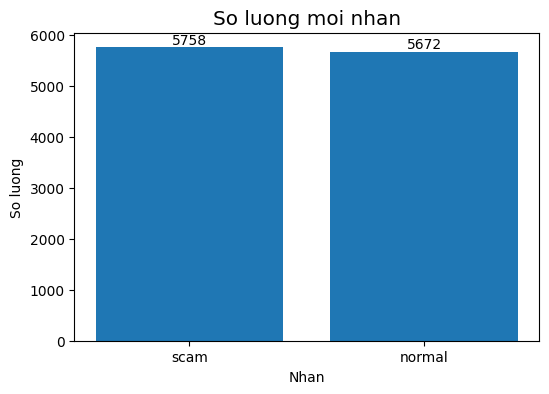

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

labels = []

# Đọc file dataset
with open("fasttext_dataset.txt", "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()

        # Bỏ dòng rỗng
        if not line:
            continue

        # Lấy label
        label = line.split()[0]
        labels.append(label)

# Đếm số lượng
counter = Counter(labels)

print(counter)

# Tách dữ liệu
x = [label.replace("__label__", "") for label in counter.keys()]
y = list(counter.values())

# Vẽ biểu đồ
plt.figure(figsize=(6,4))
bars = plt.bar(x, y)
plt.style.use("ggplot")

# Hiện số trên cột
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        str(height),
        ha='center',
        va='bottom'
    )

plt.title("So luong moi nhan")
plt.xlabel("Nhan")
plt.ylabel("So luong")
plt.show()

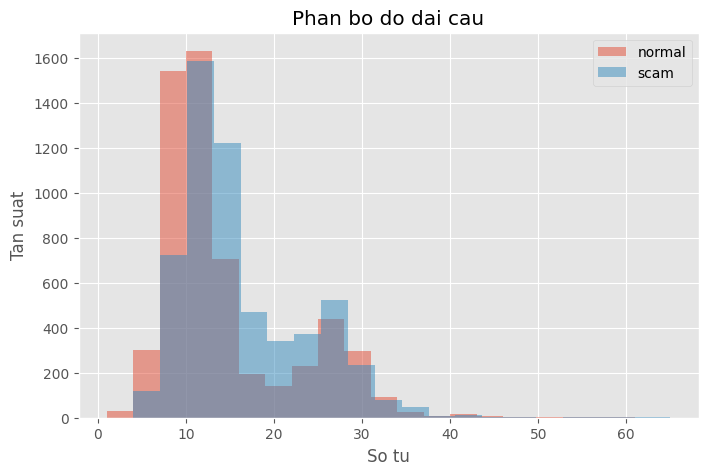

In [ ]:
import matplotlib.pyplot as plt

scam_lengths = []
normal_lengths = []

with open("fasttext_dataset.txt", "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()

        if not line:
            continue

        parts = line.split(maxsplit=1)

        if len(parts) < 2:
            continue

        label, text = parts

        length = len(text.split())

        if label == "__label__scam":
            scam_lengths.append(length)
        else:
            normal_lengths.append(length)

plt.figure(figsize=(8,5))

plt.hist(normal_lengths, bins=20, alpha=0.5, label="normal")
plt.hist(scam_lengths, bins=20, alpha=0.5, label="scam")

plt.title("Phan bo do dai cau")
plt.xlabel("So tu")
plt.ylabel("Tan suat")

plt.legend()

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

lengths = []

# Đọc dataset
with open("fasttext_dataset.txt", "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()

        if not line:
            continue

        parts = line.split(maxsplit=1)

        # bỏ dòng lỗi
        if len(parts) < 2:
            continue

        label, text = parts

        # đếm số từ
        length = len(text.split())

        lengths.append(length)
print("Trung binh:", np.mean(lengths))
print("Median:", np.median(lengths))
print("Max:", max(lengths))
print("Min:", min(lengths))

Trung binh: 15.353893263342082
Median: 13.0
Max: 65
Min: 1


In [ ]:
# ==========================================
# XEM MỘT PHẦN DỮ LIỆU FASTTEXT
# ==========================================

with open("fasttext_dataset.txt", "r", encoding="utf-8") as f:
    data = f.readlines()

print("Tong so dong:", len(data))

print("\n===== 10 DONG DAU =====\n")

for line in data[:10]:
    print(line.strip())

Tong so dong: 11430

===== 10 DONG DAU =====

__label__scam Chị thao tác theo em nha nếu chậm có thể bị gián đoạn giao dịch
__label__normal anh check giúp em giao dịch thành công chưa
__label__scam alo cj Lan hả e bên kho đây nè ui nãy gọi mãi ko dc
__label__scam dạ thật ra hệ thống tự xử lý gần xong rồi mà còn lệch phiên đăng nhập
__label__normal Chị mới mở tài khoản tiết kiệm
__label__scam ui chắc em ko nhớ đâu
__label__normal alo chị shipper nè em đứng dưới chung cư rồi
__label__normal chị đọc em mã xác minh canva với
__label__normal Chị mới mở tài khoản ngân hàng online
__label__normal alo wifi nhà em lag coi youtube cũng đứng


Tiền xử lý dữ liệu FastText

In [ ]:
# ==========================================
# TIEN XU LY DU LIEU FASTTEXT
# ==========================================

import re
import random
from collections import Counter

# ==========================================
# DOC FILE
# ==========================================

input_file = "fasttext_dataset.txt"
output_file = "fasttext_dataset_clean.txt"

with open(input_file, "r", encoding="utf-8") as f:
    raw_data = f.readlines()

print("Tong so dong ban dau:", len(raw_data))

# ==========================================
# HAM CHUAN HOA TEXT
# ==========================================

def clean_text(text):

    # chuyển chữ thường
    text = text.lower()

    # bỏ link
    text = re.sub(r"http\\S+|www\\.\\S+", " ", text)

    # bỏ số điện thoại dài
    text = re.sub(r"\\b\\d{8,15}\\b", " ", text)

    # bỏ ký tự đặc biệt
    text = re.sub(r"[^\w\s]", " ", text)

    # giảm ký tự lặp
    # vd: alooooo -> aloo
    text = re.sub(r"(.)\\1{2,}", r"\\1\\1", text)

    # bỏ khoảng trắng thừa
    text = " ".join(text.split())

    return text


# ==========================================
# TIEN XU LY
# ==========================================

clean_data = []

for line in raw_data:

    line = line.strip()

    # bỏ dòng rỗng
    if not line:
        continue

    # kiểm tra format
    parts = line.split(maxsplit=1)

    if len(parts) < 2:
        continue

    label, text = parts

    # kiểm tra label hợp lệ
    if label not in ["__label__scam", "__label__normal"]:
        continue

    # làm sạch text
    text = clean_text(text)

    # kiểm tra text sau xử lý
    if not text:
        continue

    # kiểm tra độ dài câu
    word_count = len(text.split())

    # bỏ câu quá ngắn
    if word_count < 5:
        continue

    # bỏ câu quá dài
    if word_count > 40:
        continue

    # ghép lại
    new_line = f"{label} {text}"

    clean_data.append(new_line)

print("Sau tien xu ly:", len(clean_data))

# ==========================================
# KIEM TRA TRUNG
# ==========================================

counter_before = Counter(clean_data)

duplicate_count = sum(1 for c in counter_before.values() if c > 1)

print("So cau bi trung:", duplicate_count)

# ==========================================
# LOAI TRUNG
# ==========================================

clean_data = list(dict.fromkeys(clean_data))

print("Sau loai trung:", len(clean_data))

# ==========================================
# XAO TRON DU LIEU
# ==========================================

random.shuffle(clean_data)

# ==========================================
# GHI FILE MOI
# ==========================================

with open(output_file, "w", encoding="utf-8") as f:
    for line in clean_data:
        f.write(line + "\n")

print("Da luu file:", output_file)

# ==========================================
# THONG KE NHAN
# ==========================================

labels = [line.split()[0] for line in clean_data]

counter = Counter(labels)

print("\n===== THONG KE NHAN =====")
for label, count in counter.items():
    print(label, ":", count)

# ==========================================
# THONG KE DO DAI CAU
# ==========================================

lengths = [len(line.split()[1:]) for line in clean_data]

avg_len = sum(lengths) / len(lengths)

print("\n===== THONG KE DO DAI =====")
print("Cau ngan nhat :", min(lengths))
print("Cau dai nhat  :", max(lengths))
print("Trung binh    :", round(avg_len, 2))

# ==========================================
# XEM THU 10 DONG
# ==========================================

print("\n===== 10 DONG SAU XU LY =====\n")

for line in clean_data[:10]:
    print(line)

Tong so dong ban dau: 11430
Sau tien xu ly: 11281
So cau bi trung: 666
Sau loai trung: 10390
Da luu file: fasttext_dataset_clean.txt

===== THONG KE NHAN =====
__label__normal : 4843
__label__scam : 5547

===== THONG KE DO DAI =====
Cau ngan nhat : 5
Cau dai nhat  : 40
Trung binh    : 15.34

===== 10 DONG SAU XU LY =====

__label__normal ui app ví điện tử hôm nay lỗi hay sao á
__label__scam em gọi từ viện kiểm sát anh đang liên quan vụ án
__label__scam chị nghe em nói xíu bên em đang đồng bộ lại dữ liệu thôi không phải lỗi gì lớn
__label__scam chị ơi tk icloud bị đăng nhập ở thiết bị khác chị vào link này đăng nhập lại để đổi pass gấp ko mất dữ liệu
__label__scam chị cứ giữ máy đó em chuyển bộ phận đối soát vào hỗ trợ tiếp cho đúng quy trình
__label__scam alo anh còn nhớ em ko bữa trước mình trao đổi vụ gian hàng á em gọi followup thôi
__label__normal dạ chị check thử tiền em ck tiền bàn ăn chưa
__label__scam chị đang bận hả thôi em hỏi nhanh thôi chứ giờ em hơi rối
__label__normal chị

Train FastText

In [ ]:
!pip install numpy==1.26.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 75.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>

In [ ]:
!pip install fasttext

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 1.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.4-py3-none-any.whl.metadata (10 kB)
Using cached pybind11-3.0.4-py3-none-any.whl (314 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312-cp312-linux_x86_64.whl size=4653914 sha256=2c3024c4040d3e917255ab447d005e1b9b21483d48df36469a4dcc409b5d49e2
  Stored in directory: /root/.cache/pip/wheels/20/27/95/a7baf1b435f1cbde017cabdf1e9688526d2b0e929255a359c6
Successfully built fasttext


Total samples: 10390
Train: 8312
Test : 2078

Training FastText...

Saved model.

===== FASTTEXT RESULT =====
Samples : 2078
Precision: 0.9567
Recall   : 0.9567

===== METRICS =====
Accuracy : 0.9567
F1 Macro : 0.9566
F1 Scam  : 0.9584

===== CLASSIFICATION REPORT =====

                 precision    recall  f1-score   support

__label__normal     0.9538    0.9557    0.9548       994
  __label__scam     0.9593    0.9576    0.9584      1084

       accuracy                         0.9567      2078
      macro avg     0.9566    0.9566    0.9566      2078
   weighted avg     0.9567    0.9567    0.9567      2078



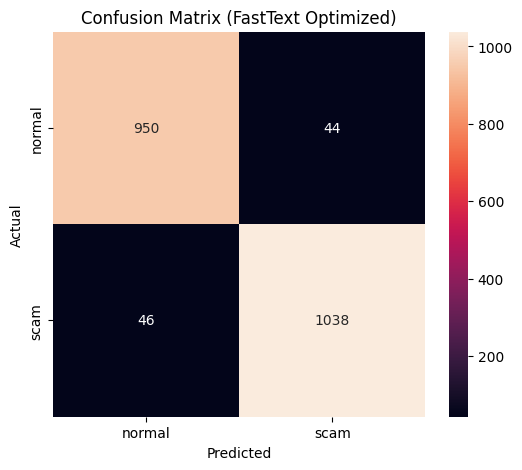


===== REAL TEST =====


Text: anh nhập mã otp giúp em với
Prediction: __label__normal
Confidence: 1.0

Text: tài khoản của bạn bị khóa tạm thời
Prediction: __label__scam
Confidence: 1.0

Text: shipper đang đứng trước cửa
Prediction: __label__normal
Confidence: 1.0

Text: mẹ ơi tối nay con về ăn cơm
Prediction: __label__normal
Confidence: 1.0


In [ ]:
# ==========================================
# FASTTEXT SCAM DETECTION - OPTIMIZED VERSION
# ==========================================

import fasttext
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# LOAD DATA
# ==========================================

input_file = "fasttext_dataset_clean.txt"

with open(input_file, "r", encoding="utf-8") as f:
    data = f.readlines()

print("Total samples:", len(data))

# ==========================================
# SPLIT DATA
# ==========================================

train_data, test_data = train_test_split(
    data,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

with open("train.txt", "w", encoding="utf-8") as f:
    f.writelines(train_data)

with open("test.txt", "w", encoding="utf-8") as f:
    f.writelines(test_data)

print("Train:", len(train_data))
print("Test :", len(test_data))

# ==========================================
# TRAIN FASTTEXT (OPTIMIZED)
# ==========================================

print("\nTraining FastText...\n")

model = fasttext.train_supervised(
    input="train.txt",

    # 🔥 learning rate tối ưu
    lr=0.5,

    # 🔥 epoch tốt cho generalization
    epoch=30,

    # 🔥 quan trọng nhất cho scam
    wordNgrams=3,

    # embedding size
    dim=100,

    # subword (rất quan trọng cho tiếng Việt)
    minn=2,
    maxn=5,

    minCount=1,

    # 🔥 best cho binary classification
    loss="ova",

    # tăng khả năng nhớ từ hiếm
    bucket=2000000,

    # tăng tốc training
    thread=4
)

# ==========================================
# SAVE MODEL
# ==========================================

model.save_model("scam_fasttext_optimized.bin")
print("Saved model.")

# ==========================================
# EVALUATION (FASTTEXT BUILT-IN)
# ==========================================

result = model.test("test.txt")

print("\n===== FASTTEXT RESULT =====")
print("Samples :", result[0])
print("Precision:", round(result[1], 4))
print("Recall   :", round(result[2], 4))

# ==========================================
# CUSTOM EVALUATION (IMPORTANT)
# ==========================================

y_true = []
y_pred = []

with open("test.txt", "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue

        parts = line.split(maxsplit=1)
        if len(parts) < 2:
            continue

        true_label, text = parts

        pred = model.predict(text)[0][0]

        y_true.append(true_label)
        y_pred.append(pred)

# ==========================================
# METRICS
# ==========================================

acc = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average="macro")
f1_scam = f1_score(y_true, y_pred, pos_label="__label__scam")

print("\n===== METRICS =====")
print("Accuracy :", round(acc, 4))
print("F1 Macro :", round(f1_macro, 4))
print("F1 Scam  :", round(f1_scam, 4))

print("\n===== CLASSIFICATION REPORT =====\n")
print(classification_report(y_true, y_pred, digits=4))

# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["normal", "scam"],
    yticklabels=["normal", "scam"]
)
plt.title("Confusion Matrix (FastText Optimized)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==========================================
# REAL TEST CASES
# ==========================================

print("\n===== REAL TEST =====\n")

test_sentences = [
    "anh nhập mã otp giúp em với",
    "tài khoản của bạn bị khóa tạm thời",
    "shipper đang đứng trước cửa",
    "mẹ ơi tối nay con về ăn cơm"
]

for sentence in test_sentences:

    label, prob = model.predict(sentence)

    print("\nText:", sentence)
    print("Prediction:", label[0])
    print("Confidence:", round(prob[0], 4))

In [ ]:
# ==========================================
# FASTTEXT REAL TEST TOOL
# ==========================================

import fasttext

# ==========================================
# LOAD MODEL
# ==========================================

model_path = "/content/scam_fasttext_mobile.bin"

model = fasttext.load_model(model_path)

print("Loaded model:", model_path)

# ==========================================
# TEST DATA
# ==========================================

test_sentences = [

]

# ==========================================
# PREDICT
# ==========================================

print("\n===== TEST RESULT =====\n")

scam_count = 0
normal_count = 0

for text in test_sentences:

    labels, probs = model.predict(text)

    label = labels[0]
    confidence = probs[0]

    if label == "__label__scam":
        scam_count += 1
        result = "SCAM"
    else:
        normal_count += 1
        result = "NORMAL"

    print("TEXT       :", text)
    print("PREDICTION :", result)
    print("CONFIDENCE :", round(confidence, 4))

    # cảnh báo confidence thấp
    if confidence < 0.75:
        print("⚠️ WARNING: confidence thấp")

    print("-" * 50)

# ==========================================
# SUMMARY
# ==========================================

print("\n===== SUMMARY =====")
print("Scam   :", scam_count)
print("Normal :", normal_count)

# ==========================================
# REALTIME INPUT
# ==========================================

print("\n===== REALTIME TEST =====")
print("Nhap 'exit' de thoat\n")

while True:

    text = input("Nhap tin nhan: ")

    if text.lower() == "exit":
        break

    labels, probs = model.predict(text)

    label = labels[0]
    confidence = probs[0]

    if label == "__label__scam":
        result = "🚨 SCAM"
    else:
        result = "✅ NORMAL"

    print("\nKet qua :", result)
    print("Do tin cay:", round(confidence, 4))

    # phân tích mức độ nguy hiểm
    if confidence > 0.95:
        print("Muc do: RAT CAO")

    elif confidence > 0.80:
        print("Muc do: CAO")

    elif confidence > 0.65:
        print("Muc do: TRUNG BINH")

    else:
        print("Muc do: THAP")

    print()

Loaded model: /content/scam_fasttext_mobile.bin

===== TEST RESULT =====


===== SUMMARY =====
Scam   : 0
Normal : 0

===== REALTIME TEST =====
Nhap 'exit' de thoat

Nhap tin nhan: em gọi bên ngân hàng đây

Ket qua : ✅ NORMAL
Do tin cay: 0.9979
Muc do: RAT CAO

Nhap tin nhan: EM GỌI BÊN NGÂN HÀNG ĐÂY

Ket qua : ✅ NORMAL
Do tin cay: 1.0
Muc do: RAT CAO

Nhap tin nhan: EM GỌI BÊN NGÂN HÀNG ĐÂY ANH CÓ GIAO DỊCH GẦN ĐÂY KHÔNG

Ket qua : ✅ NORMAL
Do tin cay: 0.9939
Muc do: RAT CAO

Nhap tin nhan: em gọi bên ngân hàng đây anh có giao dịch gần đây không

Ket qua : 🚨 SCAM
Do tin cay: 0.9939
Muc do: RAT CAO

Nhap tin nhan: exit
